In [1]:
# ============================================================================================================================
# Step 1. Setup SP500 and its components
# ============================================================================================================================
import yfinance as yf
import pandas as pd

# SP 500 成分股
tickers = pd.read_html("https://en.wikipedia.org/wiki/List_of_S%26P_500_companies")[0]['Symbol'].tolist()
tickers = [ticker.replace('.', '-') for ticker in tickers]

# period
start_date = "2017-01-01"
end_date = "2025-06-10"

# data
data = yf.download(tickers, start=start_date, end=end_date, group_by='ticker', auto_adjust=False)

# close_df (row: Date, col: tickers) and volume (row: Date, col: tickers)
close_df = pd.DataFrame({ticker: data[ticker]['Close'] for ticker in tickers if ticker in data.columns.levels[0]})
volume_df = pd.DataFrame({ticker: data[ticker]['Volume'] for ticker in tickers if ticker in data.columns.levels[0]})

# sp500 (row: Date, col: index)
sp500 = yf.download('^GSPC', start=start_date, end=end_date)['Close']

[*********************100%***********************]  503 of 503 completed

1 Failed download:
['VRSN']: DNSError('Failed to perform, curl: (6) Could not resolve host: query2.finance.yahoo.com. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [2]:
# ============================================================================================================================
# Step 2. 只要缺失值的 column 就去掉
# ============================================================================================================================
# 原始 ticker
orig_tickers = close_df.columns.tolist()

# 丟掉任何含有 NaN 的 column
close_df = close_df.dropna(axis=1)
volume_df = volume_df.dropna(axis=1)

# 被移除的 ticker
removed = set(orig_tickers) - set(close_df.columns)
print(f"Removed {len(removed)} tickers with missing data:", removed)


Removed 26 tickers with missing data: {'COIN', 'CRWD', 'DOW', 'CEG', 'CARR', 'KVUE', 'SW', 'CTVA', 'DASH', 'VLTO', 'VICI', 'ABNB', 'SOLV', 'OTIS', 'MRNA', 'EXE', 'IR', 'FOXA', 'GEHC', 'INVH', 'PLTR', 'UBER', 'GEV', 'DAY', 'FOX', 'VRSN'}


In [3]:
# ============================================================================================================================
# Step 3. 切分train, test, simulation
# ===========================================================================================================================
# 1. 時間區間
train_end = "2022-06-30"
test_start, test_end = "2022-07-01", "2023-06-30"
sim_start = "2023-07-01"
sim_end = "2025-06-10"

# 2. 切分
close_train = close_df.loc[:train_end]
close_test  = close_df.loc[test_start:test_end]
close_sim   = close_df.loc[sim_start:sim_end]

volume_train = volume_df.loc[:train_end]
volume_test  = volume_df.loc[test_start:test_end]
volume_sim   = volume_df.loc[sim_start:sim_end]

# 3. 保存成 CSV
close_train.to_csv("close_train.csv", index=True)
close_test.to_csv("close_test.csv",   index=True)
close_sim.to_csv("close_sim.csv",     index=True)

volume_train.to_csv("volume_train.csv",     index=True)
volume_test.to_csv("volume_test.csv",   index=True)
volume_sim.to_csv("volume_sim.csv",     index=True)

print("完成")


def make_long_df(close_df, volume_df):
    """把寬表的 close 和 volume 轉成長表，丟掉 NaN"""
    close_s = close_df.stack().rename('close')
    vol_s   = volume_df.stack().rename('volume')
    df = pd.concat([close_s, vol_s], axis=1).dropna().reset_index()
    df.columns = ['date', 'ticker', 'close', 'volume']
    return df

# 1. 構造長表
train_df = make_long_df(close_train, volume_train)
test_df  = make_long_df(close_test,  volume_test)
sim_df   = make_long_df(close_sim,   volume_sim)


完成


In [ ]:
# 1. 在 train_df 上計算每隻股票的 mean/std
stats = (
    train_df
    .groupby('ticker')['close']
    .agg(['mean','std'])
    .rename(columns={'mean':'close_mean','std':'close_std'})
)

# 2. 標準化
def add_close_zscore(df, stats):
    # 把 stats join 到 df
    df = df.join(stats, on='ticker')
    # z-score
    df['close_z'] = (df['close'] - df['close_mean']) / df['close_std']
    return df.drop(columns=['close_mean','close_std'])

# 3. 轉換
train_df_z = add_close_zscore(train_df, stats)
test_df_z  = add_close_zscore(test_df,  stats)
sim_df_z   = add_close_zscore(sim_df,   stats)

# 4. 測試
print(train_df_z[['ticker','close','close_z']].groupby('ticker').agg(['mean','std']).loc['AAPL'])



close    mean    8.235561e+01
         std     4.596328e+01
close_z  mean   -1.125476e-16
         std     1.000000e+00
Name: AAPL, dtype: float64


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D,
    BatchNormalization, LSTM,
    Dropout, Dense,
    GlobalAveragePooling1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# -----------------------------------------------------------------------------
# 1. 股票的 close & volume mean/std
# -----------------------------------------------------------------------------
stats_close = (
    train_df
    .groupby('ticker')['close']
    .agg(['mean','std'])
    .rename(columns={'mean':'c_mean','std':'c_std'})
)
stats_vol = (
    train_df
    .groupby('ticker')['volume']
    .agg(['mean','std'])
    .rename(columns={'mean':'v_mean','std':'v_std'})
)

# -----------------------------------------------------------------------------
# 2. 標準化、下一日標準化價格
# -----------------------------------------------------------------------------
def add_zscore_and_target(df, stats_close, stats_vol):
    df = df.copy()
    df = df.merge(stats_close, left_on='ticker', right_index=True, how='left')
    df = df.merge(stats_vol,   left_on='ticker', right_index=True, how='left')
    df['close_z']  = (df['close']  - df['c_mean']) / df['c_std']
    df['volume_z'] = (df['volume'] - df['v_mean']) / df['v_std']
    df = df.sort_values(['ticker','date'])
    df['next_close_z'] = df.groupby('ticker')['close_z'].shift(-1)
    df = df.dropna(subset=['close_z','volume_z','next_close_z'])
    return df.drop(columns=['c_mean','c_std','v_mean','v_std'])

train_z = add_zscore_and_target(train_df, stats_close, stats_vol)
test_z  = add_zscore_and_target(test_df,  stats_close, stats_vol)
sim_z   = add_zscore_and_target(sim_df,   stats_close, stats_vol)

# -----------------------------------------------------------------------------
# 3. 建立window X, y_z, ticker_list
# -----------------------------------------------------------------------------
WINDOW_SIZE = 10
FEATURES    = ['close_z','volume_z']

def make_sequences(df_long, window_size=WINDOW_SIZE):
    X_list, y_list, t_list = [], [], []
    for tk, sub in df_long.groupby('ticker'):
        sub = sub.sort_values('date')
        feat_arr   = sub[FEATURES].values
        target_arr = sub['next_close_z'].values
        for i in range(len(feat_arr) - window_size + 1):
            X_list.append(feat_arr[i:i+window_size])
            y_list.append(target_arr[i+window_size-1])
            t_list.append(tk)
    return np.array(X_list), np.array(y_list), np.array(t_list)

X_train, y_train_z, train_tks = make_sequences(train_z)
X_test,  y_test_z,  test_tks  = make_sequences(test_z)
X_sim,   y_sim_z,   sim_tks   = make_sequences(sim_z)

# -----------------------------------------------------------------------------
# 4. CNN → LSTM → GlobalAveragePooling1D
# -----------------------------------------------------------------------------
BATCH_SIZE = 256
EPOCHS     = 50
LR         = 1e-3

inp = Input(shape=(WINDOW_SIZE, len(FEATURES)))
x = Conv1D(32, 3, activation='relu', padding='same')(inp)
x = BatchNormalization()(x)
x = MaxPooling1D(2)(x)

x = Conv1D(64, 3, activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling1D(2)(x)

lstm_out = LSTM(64, return_sequences=True)(x)

context = GlobalAveragePooling1D()(lstm_out)
context = Dropout(0.2)(context)
out     = Dense(1)(context)

model = Model(inp, out)
model.compile(optimizer=Adam(LR), loss='mse', metrics=['mae'])
model.summary()

# -----------------------------------------------------------------------------
# 5. Training
# -----------------------------------------------------------------------------
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model.fit(
    X_train, y_train_z,
    validation_data=(X_test, y_test_z),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[es],
    verbose=1
)

# -----------------------------------------------------------------------------
# 7. sim_pred、反標準化
# -----------------------------------------------------------------------------
y_sim_pred_z = model.predict(X_sim, batch_size=BATCH_SIZE).flatten()

c_means = stats_close.loc[sim_tks, 'c_mean'].values
c_stds  = stats_close.loc[sim_tks, 'c_std'].values

y_sim_true_price = y_sim_z    * c_stds + c_means
y_sim_pred_price = y_sim_pred_z * c_stds + c_means

mse_price = np.mean((y_sim_true_price - y_sim_pred_price)**2)
mae_price = np.mean(np.abs(y_sim_true_price - y_sim_pred_price))
print(f"Sim Price  MSE: {mse_price:.4f}, MAE: {mae_price:.4f}")


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 10, 32)         │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 5, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 5, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 2, 64)          │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,905 (155.88 KB)

 Trainable params: 39,713 (155.13 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/50
2559/2559 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 0.0430 - mae: 0.1372 - val_loss: 0.1355 - val_mae: 0.1248
Epoch 2/50
2559/2559 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 0.0159 - mae: 0.0894 - val_loss: 0.1182 - val_mae: 0.1061
Epoch 3/50
2559/2559 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 0.0148 - mae: 0.0859 - val_loss: 0.1096 - val_mae: 0.0917
Epoch 4/50
2559/2559 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 0.0142 - mae: 0.0838 - val_loss: 0.1082 - val_mae: 0.0911
Epoch 5/50
2559/2559 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 0.0138 - mae: 0.0826 - val_loss: 0.1063 - val_mae: 0.0930
Epoch 6/50
2559/2559 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 0.0132 - mae: 0.0809 - val_loss: 0.1076 - val_mae: 0.0957
Epoch 7/50
2559/2559 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 0.0131 - mae: 0.0806 - val_loss: 0.1057 - val_mae: 0.0898
Epoch 8/50
2559/2559 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 0.0130 - mae: 0.0800 - val_loss: 0.1021 - val_mae: 0.0972
Epoch 9/50
2559/2559 ━━━━━━━━━━━

886/886 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


/var/folders/w9/s0cxc9854cx9lr7g5cl7ph600000gn/T/ipykernel_99625/1686144662.py:89: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  daily_ret += wt * float(r)
/var/folders/w9/s0cxc9854cx9lr7g5cl7ph600000gn/T/ipykernel_99625/1686144662.py:89: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  daily_ret += wt * float(r)
/var/folders/w9/s0cxc9854cx9lr7g5cl7ph600000gn/T/ipykernel_99625/1686144662.py:89: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  daily_ret += wt * float(r)
/var/folders/w9/s0cxc9854cx9lr7g5cl7ph600000gn/T/ipykernel_99625/1686144662.py:89: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  daily_r

Ann Return: 70.33%
Ann Volatility: 43.08%
Sharpe Ratio: 1.63
Max Drawdown: -33.21%


/var/folders/w9/s0cxc9854cx9lr7g5cl7ph600000gn/T/ipykernel_99625/1686144662.py:98: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ann_ret = perf['cum_nav'][-1]**(252/len(perf)) - 1


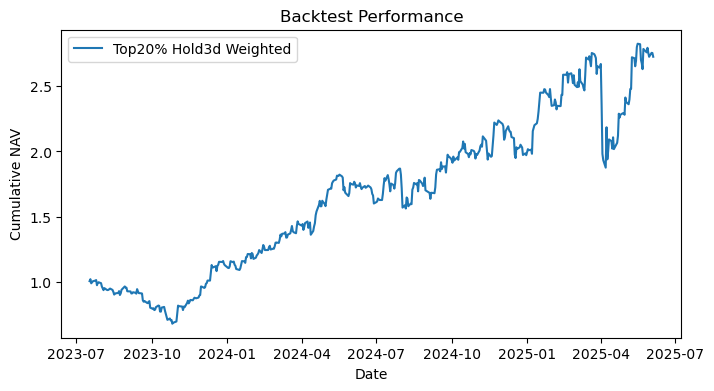

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# 1) 重寫 make_sequences，帶回原始日期
WINDOW = 10
FEATURES = ['close_z','volume_z']

def make_sequences_with_dates(df_long, window_size=WINDOW):
    X_list, t_list, d_list = [], [], []
    for tk, sub in df_long.groupby('ticker'):
        sub = sub.sort_values('date')
        feat_arr   = sub[FEATURES].values
        date_arr   = sub['date'].values
        for i in range(len(feat_arr) - window_size):
            X_list.append(feat_arr[i:i+window_size])
            t_list.append(tk)
            d_list.append(date_arr[i+window_size-1])
    return np.array(X_list), np.array(t_list), np.array(d_list)

X_sim, sim_tks, sim_dates = make_sequences_with_dates(sim_z)

# 2) 預測標準化價格
y_sim_pred_z = model.predict(X_sim, batch_size=256).flatten()

# 3) 建構 sim_long_seq
sim_pred = pd.DataFrame({
    'date':    sim_dates,
    'ticker':  sim_tks,
    'pred_z':  y_sim_pred_z
})

# 加上 close
sim_pred = sim_pred.merge(
    sim_z[['date','ticker','close']], 
    on=['date','ticker'], how='left'
)

# 4) 反標準化
sim_pred = sim_pred.merge(
    stats_close, left_on='ticker', right_index=True, how='left'
)
sim_pred['pred_next'] = sim_pred['pred_z'] * sim_pred['c_std'] + sim_pred['c_mean']

# 最終的 long_seq
sim_long_seq = sim_pred[['date','ticker','close','pred_next']].dropna()

# ----------------------------------
# 5) 回測
# ----------------------------------
df = sim_long_seq.copy()
df['pred_ret']   = df['pred_next'] / df['close'] - 1
df['actual_ret'] = df.groupby('ticker')['close'].shift(-1) / df['close'] - 1
df = df.dropna(subset=['pred_ret','actual_ret'])

dates = sorted(df['date'].unique())
positions = {}  # ticker -> list of (entry_date, weight)
records = []

for today in dates:
    today_df = df[df['date']==today]
    if today_df.empty:
        records.append({'date': today, 'daily_ret': 0.0})
        continue

    # 前20%
    topn = int(len(today_df)*0.2) or 1
    top = today_df.nlargest(topn, 'pred_ret')

    # 權重
    w = top['pred_ret']
    w = w / w.sum()

    # 買進
    for tk, wt in zip(top['ticker'], w):
        positions.setdefault(tk, []).append((today, float(wt)))

    # 日收益
    daily_ret = 0.0
    new_pos = {}
    for tk, slots in positions.items():
        for entry, wt in slots:
            hold_days = (today - entry).days
            if hold_days < 3:
                # actual_ret
                r = df.loc[(df['date']==today)&(df['ticker']==tk),'actual_ret']
                if not r.empty:
                    daily_ret += wt * float(r)
                new_pos.setdefault(tk, []).append((entry, wt))
    positions = new_pos
    records.append({'date': today, 'daily_ret': daily_ret})

perf = pd.DataFrame(records).set_index('date')
perf['cum_nav'] = (1 + perf['daily_ret']).cumprod()

# 6) 指標
ann_ret = perf['cum_nav'][-1]**(252/len(perf)) - 1
ann_vol = perf['daily_ret'].std()*np.sqrt(252)
sharpe  = ann_ret/ann_vol
drawdown = (perf['cum_nav']/perf['cum_nav'].cummax() - 1).min()

print(f"Ann Return: {ann_ret:.2%}")
print(f"Ann Volatility: {ann_vol:.2%}")
print(f"Sharpe Ratio: {sharpe:.2f}")
print(f"Max Drawdown: {drawdown:.2%}")

# 7) 圖
plt.figure(figsize=(8,4))
plt.plot(perf['cum_nav'], label='Top20% Hold3d Weighted')
plt.title('Backtest Performance')
plt.ylabel('Cumulative NAV')
plt.xlabel('Date')
plt.legend()
plt.show()


/var/folders/w9/s0cxc9854cx9lr7g5cl7ph600000gn/T/ipykernel_99625/3257525142.py:43: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  daily_ret += w * float(ret)
/var/folders/w9/s0cxc9854cx9lr7g5cl7ph600000gn/T/ipykernel_99625/3257525142.py:43: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  daily_ret += w * float(ret)
/var/folders/w9/s0cxc9854cx9lr7g5cl7ph600000gn/T/ipykernel_99625/3257525142.py:43: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  daily_ret += w * float(ret)
/var/folders/w9/s0cxc9854cx9lr7g5cl7ph600000gn/T/ipykernel_99625/3257525142.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element fro

Trades: 44745
Win Rate: 50.91%
Avg Trade Return: -0.02%
Ann Return: 13.98%
Ann Vol: 43.13%
Sharpe: 0.32
Max Drawdown: -40.36%


/var/folders/w9/s0cxc9854cx9lr7g5cl7ph600000gn/T/ipykernel_99625/3257525142.py:67: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ann_return     = perf['cum_nav'][-1]**(252/len(perf)) - 1


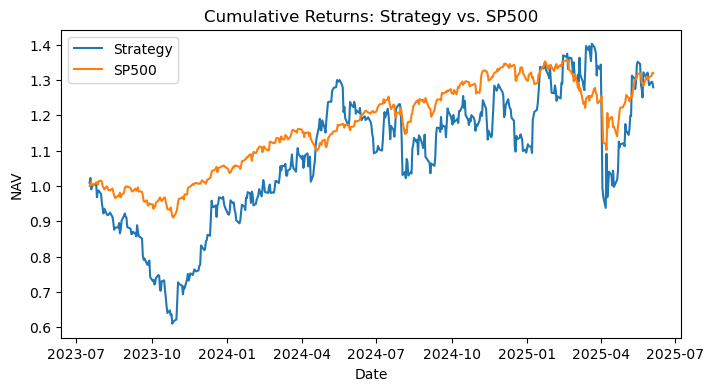

In [ ]:
# -----------------------------------------------------------------------------
# 10. 考慮交易成本與回測統計（前20%）
# -----------------------------------------------------------------------------
cost_rate = 0.0008  # 0.08% per trade side

# 數據
df = sim_long_seq.copy()
df['pred_ret']   = df['pred_next'] / df['close'] - 1
df['actual_ret'] = df.groupby('ticker')['close'].shift(-1) / df['close'] - 1
df = df.dropna(subset=['pred_ret','actual_ret'])

# 回測容器
dates      = sorted(df['date'].unique())
positions  = {}  # ticker -> list of (entry_date, weight, entry_price)
perf_rec   = []
trade_rets = []

for today in dates:
    today_df = df[df['date']==today]
    # 前20%
    n    = max(int(len(today_df)*0.2), 1)
    top  = today_df.nlargest(n, 'pred_ret').copy()
    wts  = top['pred_ret'] / top['pred_ret'].sum()

    entry_cost = 0.0
    for tk, w in zip(top['ticker'], wts):
        price = top.loc[top['ticker']==tk, 'close'].values[0]
        # 成本
        entry_cost += w * cost_rate
        positions.setdefault(tk, []).append((today, float(w), float(price)))

    # 日收益、平倉
    daily_ret  = 0.0
    exit_cost  = 0.0
    new_pos    = {}
    for tk, slots in positions.items():
        for entry_date, w, entry_price in slots:
            hold_days = (today - entry_date).days
            if hold_days < 3:
                # 繼續持有
                ret = df.loc[(df['date']==today)&(df['ticker']==tk), 'actual_ret']
                if not ret.empty:
                    daily_ret += w * float(ret)
                new_pos.setdefault(tk, []).append((entry_date, w, entry_price))
            else:
                # 到期平倉
                exit_price = df.loc[(df['date']==today)&(df['ticker']==tk), 'close'].values
                if exit_price.size:
                    trade_ret = (float(exit_price) / entry_price - 1) - 2*cost_rate
                    trade_rets.append(trade_ret)
                    # 成本
                    exit_cost += w * cost_rate
    positions = new_pos

    # 日淨收益
    net_ret = daily_ret - entry_cost - exit_cost
    perf_rec.append({'date': today, 'daily_return': net_ret})

# 績效表
perf = pd.DataFrame(perf_rec).set_index('date')
perf['cum_nav'] = (1 + perf['daily_return']).cumprod()

# 指標
trade_count    = len(trade_rets)
win_rate       = np.mean([r>0 for r in trade_rets])
avg_trade_ret  = np.mean(trade_rets) if trade_rets else np.nan
ann_return     = perf['cum_nav'][-1]**(252/len(perf)) - 1
ann_vol        = perf['daily_return'].std()*np.sqrt(252)
sharpe         = ann_return/ann_vol
drawdown       = (perf['cum_nav']/perf['cum_nav'].cummax() - 1).min()

print(f"Trades: {trade_count}")
print(f"Win Rate: {win_rate:.2%}")
print(f"Avg Trade Return: {avg_trade_ret:.2%}")
print(f"Ann Return: {ann_return:.2%}")
print(f"Ann Vol: {ann_vol:.2%}")
print(f"Sharpe: {sharpe:.2f}")
print(f"Max Drawdown: {drawdown:.2%}")

# SP500 對比
spy = sp500.loc[perf.index]
spy_ret = spy.pct_change().fillna(0)
spy_nav = (1+spy_ret).cumprod()

# 圖
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(perf['cum_nav'], label='Strategy')
plt.plot(spy_nav,  label='SP500')
plt.title('Cumulative Returns: Strategy vs. SP500')
plt.xlabel('Date')
plt.ylabel('NAV')
plt.legend()
plt.show()


/var/folders/w9/s0cxc9854cx9lr7g5cl7ph600000gn/T/ipykernel_99625/631747932.py:43: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  daily_ret += w * float(ret)
/var/folders/w9/s0cxc9854cx9lr7g5cl7ph600000gn/T/ipykernel_99625/631747932.py:43: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  daily_ret += w * float(ret)
/var/folders/w9/s0cxc9854cx9lr7g5cl7ph600000gn/T/ipykernel_99625/631747932.py:43: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  daily_ret += w * float(ret)
/var/folders/w9/s0cxc9854cx9lr7g5cl7ph600000gn/T/ipykernel_99625/631747932.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from yo

Trades: 22137
Win Rate: 50.49%
Avg Trade Return: -0.02%
Ann Return: 20.83%
Ann Vol: 47.02%
Sharpe: 0.44
Max Drawdown: -43.26%


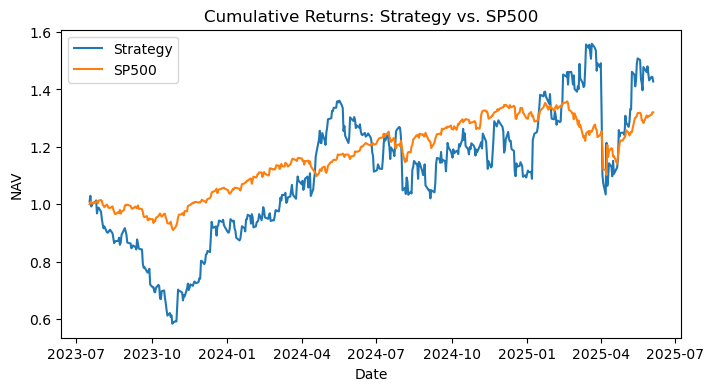

In [ ]:
# -----------------------------------------------------------------------------
# 10. 考慮交易成本與回測統計（前10%）
# -----------------------------------------------------------------------------
cost_rate = 0.0008  # 0.08% per trade side

# 數據
df = sim_long_seq.copy()
df['pred_ret']   = df['pred_next'] / df['close'] - 1
df['actual_ret'] = df.groupby('ticker')['close'].shift(-1) / df['close'] - 1
df = df.dropna(subset=['pred_ret','actual_ret'])

# 回測容器
dates      = sorted(df['date'].unique())
positions  = {}  # ticker -> list of (entry_date, weight, entry_price)
perf_rec   = []
trade_rets = []

for today in dates:
    today_df = df[df['date']==today]
    # 前10%
    n    = max(int(len(today_df)*0.1), 1)
    top  = today_df.nlargest(n, 'pred_ret').copy()
    wts  = top['pred_ret'] / top['pred_ret'].sum()

    entry_cost = 0.0
    for tk, w in zip(top['ticker'], wts):
        price = top.loc[top['ticker']==tk, 'close'].values[0]
        # 成本
        entry_cost += w * cost_rate
        positions.setdefault(tk, []).append((today, float(w), float(price)))

    # 日收益、平倉
    daily_ret  = 0.0
    exit_cost  = 0.0
    new_pos    = {}
    for tk, slots in positions.items():
        for entry_date, w, entry_price in slots:
            hold_days = (today - entry_date).days
            if hold_days < 3:
                # 繼續持有
                ret = df.loc[(df['date']==today)&(df['ticker']==tk), 'actual_ret']
                if not ret.empty:
                    daily_ret += w * float(ret)
                new_pos.setdefault(tk, []).append((entry_date, w, entry_price))
            else:
                # 到期平倉
                exit_price = df.loc[(df['date']==today)&(df['ticker']==tk), 'close'].values
                if exit_price.size:
                    trade_ret = (float(exit_price) / entry_price - 1) - 2*cost_rate
                    trade_rets.append(trade_ret)
                    # 成本
                    exit_cost += w * cost_rate
    positions = new_pos

    # 日淨收益
    net_ret = daily_ret - entry_cost - exit_cost
    perf_rec.append({'date': today, 'daily_return': net_ret})

# 績效表
perf = pd.DataFrame(perf_rec).set_index('date')
perf['cum_nav'] = (1 + perf['daily_return']).cumprod()

# 指標
trade_count    = len(trade_rets)
win_rate       = np.mean([r>0 for r in trade_rets])
avg_trade_ret  = np.mean(trade_rets) if trade_rets else np.nan
ann_return     = perf['cum_nav'][-1]**(252/len(perf)) - 1
ann_vol        = perf['daily_return'].std()*np.sqrt(252)
sharpe         = ann_return/ann_vol
drawdown       = (perf['cum_nav']/perf['cum_nav'].cummax() - 1).min()

print(f"Trades: {trade_count}")
print(f"Win Rate: {win_rate:.2%}")
print(f"Avg Trade Return: {avg_trade_ret:.2%}")
print(f"Ann Return: {ann_return:.2%}")
print(f"Ann Vol: {ann_vol:.2%}")
print(f"Sharpe: {sharpe:.2f}")
print(f"Max Drawdown: {drawdown:.2%}")

# SP500 對比
spy = sp500.loc[perf.index]
spy_ret = spy.pct_change().fillna(0)
spy_nav = (1+spy_ret).cumprod()

# 圖
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(perf['cum_nav'], label='Strategy')
plt.plot(spy_nav,  label='SP500')
plt.title('Cumulative Returns: Strategy(top 10%) vs. SP500')
plt.xlabel('Date')
plt.ylabel('NAV')
plt.legend()
plt.show()


/var/folders/w9/s0cxc9854cx9lr7g5cl7ph600000gn/T/ipykernel_99625/3655209614.py:43: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  daily_ret += w * float(ret)
/var/folders/w9/s0cxc9854cx9lr7g5cl7ph600000gn/T/ipykernel_99625/3655209614.py:43: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  daily_ret += w * float(ret)
/var/folders/w9/s0cxc9854cx9lr7g5cl7ph600000gn/T/ipykernel_99625/3655209614.py:43: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  daily_ret += w * float(ret)
/var/folders/w9/s0cxc9854cx9lr7g5cl7ph600000gn/T/ipykernel_99625/3655209614.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element fro

Trades: 33441
Win Rate: 50.65%
Avg Trade Return: -0.02%
Ann Return: 16.25%
Ann Vol: 44.69%
Sharpe: 0.36
Max Drawdown: -41.16%


/var/folders/w9/s0cxc9854cx9lr7g5cl7ph600000gn/T/ipykernel_99625/3655209614.py:67: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ann_return     = perf['cum_nav'][-1]**(252/len(perf)) - 1


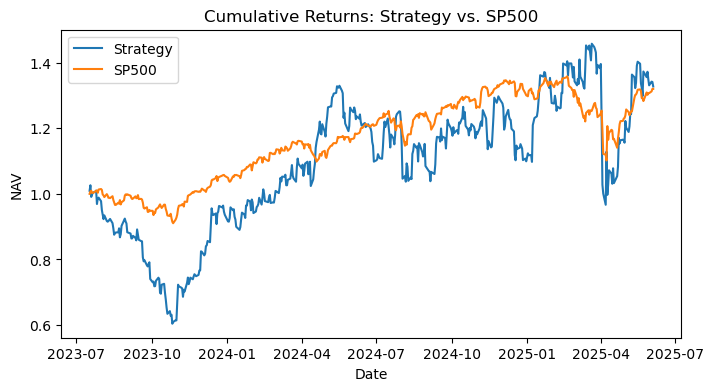

In [ ]:
# -----------------------------------------------------------------------------
# 10. 考慮交易成本與回測統計（前15%）
# -----------------------------------------------------------------------------
cost_rate = 0.0008  # 0.08% per trade side

# 數據
df = sim_long_seq.copy()
df['pred_ret']   = df['pred_next'] / df['close'] - 1
df['actual_ret'] = df.groupby('ticker')['close'].shift(-1) / df['close'] - 1
df = df.dropna(subset=['pred_ret','actual_ret'])

# 回測容器
dates      = sorted(df['date'].unique())
positions  = {}  # ticker -> list of (entry_date, weight, entry_price)
perf_rec   = []
trade_rets = []

for today in dates:
    today_df = df[df['date']==today]
    # 前15%
    n    = max(int(len(today_df)*0.15), 1)
    top  = today_df.nlargest(n, 'pred_ret').copy()
    wts  = top['pred_ret'] / top['pred_ret'].sum()

    entry_cost = 0.0
    for tk, w in zip(top['ticker'], wts):
        price = top.loc[top['ticker']==tk, 'close'].values[0]
        # 成本
        entry_cost += w * cost_rate
        positions.setdefault(tk, []).append((today, float(w), float(price)))

    # 日收益、平倉
    daily_ret  = 0.0
    exit_cost  = 0.0
    new_pos    = {}
    for tk, slots in positions.items():
        for entry_date, w, entry_price in slots:
            hold_days = (today - entry_date).days
            if hold_days < 3:
                # 繼續持有
                ret = df.loc[(df['date']==today)&(df['ticker']==tk), 'actual_ret']
                if not ret.empty:
                    daily_ret += w * float(ret)
                new_pos.setdefault(tk, []).append((entry_date, w, entry_price))
            else:
                # 到期平倉
                exit_price = df.loc[(df['date']==today)&(df['ticker']==tk), 'close'].values
                if exit_price.size:
                    trade_ret = (float(exit_price) / entry_price - 1) - 2*cost_rate
                    trade_rets.append(trade_ret)
                    # 成本
                    exit_cost += w * cost_rate
    positions = new_pos

    # 日淨收益
    net_ret = daily_ret - entry_cost - exit_cost
    perf_rec.append({'date': today, 'daily_return': net_ret})

# 績效表
perf = pd.DataFrame(perf_rec).set_index('date')
perf['cum_nav'] = (1 + perf['daily_return']).cumprod()

# 指標
trade_count    = len(trade_rets)
win_rate       = np.mean([r>0 for r in trade_rets])
avg_trade_ret  = np.mean(trade_rets) if trade_rets else np.nan
ann_return     = perf['cum_nav'][-1]**(252/len(perf)) - 1
ann_vol        = perf['daily_return'].std()*np.sqrt(252)
sharpe         = ann_return/ann_vol
drawdown       = (perf['cum_nav']/perf['cum_nav'].cummax() - 1).min()

print(f"Trades: {trade_count}")
print(f"Win Rate: {win_rate:.2%}")
print(f"Avg Trade Return: {avg_trade_ret:.2%}")
print(f"Ann Return: {ann_return:.2%}")
print(f"Ann Vol: {ann_vol:.2%}")
print(f"Sharpe: {sharpe:.2f}")
print(f"Max Drawdown: {drawdown:.2%}")

# SP500 對比
spy = sp500.loc[perf.index]
spy_ret = spy.pct_change().fillna(0)
spy_nav = (1+spy_ret).cumprod()

# 圖
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(perf['cum_nav'], label='Strategy')
plt.plot(spy_nav,  label='SP500')
plt.title('Cumulative Returns: Strategy(top 15%) vs. SP500')
plt.xlabel('Date')
plt.ylabel('NAV')
plt.legend()
plt.show()


/var/folders/w9/s0cxc9854cx9lr7g5cl7ph600000gn/T/ipykernel_99625/622799577.py:43: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  daily_ret += w * float(ret)
/var/folders/w9/s0cxc9854cx9lr7g5cl7ph600000gn/T/ipykernel_99625/622799577.py:43: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  daily_ret += w * float(ret)
/var/folders/w9/s0cxc9854cx9lr7g5cl7ph600000gn/T/ipykernel_99625/622799577.py:43: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  daily_ret += w * float(ret)
/var/folders/w9/s0cxc9854cx9lr7g5cl7ph600000gn/T/ipykernel_99625/622799577.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from yo

Trades: 10833
Win Rate: 49.92%
Avg Trade Return: 0.00%
Ann Return: 31.16%
Ann Vol: 52.04%
Sharpe: 0.60
Max Drawdown: -44.92%


/var/folders/w9/s0cxc9854cx9lr7g5cl7ph600000gn/T/ipykernel_99625/622799577.py:67: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ann_return     = perf['cum_nav'][-1]**(252/len(perf)) - 1


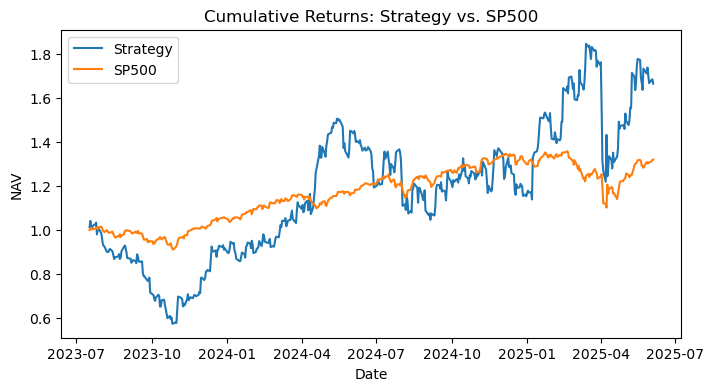

In [ ]:
# -----------------------------------------------------------------------------
# 10. 考慮交易成本與回測統計（前5%）
# -----------------------------------------------------------------------------
cost_rate = 0.0008  # 0.08% per trade side

# 數據
df = sim_long_seq.copy()
df['pred_ret']   = df['pred_next'] / df['close'] - 1
df['actual_ret'] = df.groupby('ticker')['close'].shift(-1) / df['close'] - 1
df = df.dropna(subset=['pred_ret','actual_ret'])

# 回測容器
dates      = sorted(df['date'].unique())
positions  = {}  # ticker -> list of (entry_date, weight, entry_price)
perf_rec   = []
trade_rets = []

for today in dates:
    today_df = df[df['date']==today]
    # 前5%
    n    = max(int(len(today_df)*0.05), 1)
    top  = today_df.nlargest(n, 'pred_ret').copy()
    wts  = top['pred_ret'] / top['pred_ret'].sum()

    entry_cost = 0.0
    for tk, w in zip(top['ticker'], wts):
        price = top.loc[top['ticker']==tk, 'close'].values[0]
        # 成本
        entry_cost += w * cost_rate
        positions.setdefault(tk, []).append((today, float(w), float(price)))

    # 日收益、平倉
    daily_ret  = 0.0
    exit_cost  = 0.0
    new_pos    = {}
    for tk, slots in positions.items():
        for entry_date, w, entry_price in slots:
            hold_days = (today - entry_date).days
            if hold_days < 3:
                # 繼續持有
                ret = df.loc[(df['date']==today)&(df['ticker']==tk), 'actual_ret']
                if not ret.empty:
                    daily_ret += w * float(ret)
                new_pos.setdefault(tk, []).append((entry_date, w, entry_price))
            else:
                # 到期平倉
                exit_price = df.loc[(df['date']==today)&(df['ticker']==tk), 'close'].values
                if exit_price.size:
                    trade_ret = (float(exit_price) / entry_price - 1) - 2*cost_rate
                    trade_rets.append(trade_ret)
                    # 成本
                    exit_cost += w * cost_rate
    positions = new_pos

    # 日淨收益
    net_ret = daily_ret - entry_cost - exit_cost
    perf_rec.append({'date': today, 'daily_return': net_ret})

# 績效表
perf = pd.DataFrame(perf_rec).set_index('date')
perf['cum_nav'] = (1 + perf['daily_return']).cumprod()

# 指標
trade_count    = len(trade_rets)
win_rate       = np.mean([r>0 for r in trade_rets])
avg_trade_ret  = np.mean(trade_rets) if trade_rets else np.nan
ann_return     = perf['cum_nav'][-1]**(252/len(perf)) - 1
ann_vol        = perf['daily_return'].std()*np.sqrt(252)
sharpe         = ann_return/ann_vol
drawdown       = (perf['cum_nav']/perf['cum_nav'].cummax() - 1).min()

print(f"Trades: {trade_count}")
print(f"Win Rate: {win_rate:.2%}")
print(f"Avg Trade Return: {avg_trade_ret:.2%}")
print(f"Ann Return: {ann_return:.2%}")
print(f"Ann Vol: {ann_vol:.2%}")
print(f"Sharpe: {sharpe:.2f}")
print(f"Max Drawdown: {drawdown:.2%}")

# SP500 對比
spy = sp500.loc[perf.index]
spy_ret = spy.pct_change().fillna(0)
spy_nav = (1+spy_ret).cumprod()

# 圖
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(perf['cum_nav'], label='Strategy')
plt.plot(spy_nav,  label='SP500')
plt.title('Cumulative Returns: Strategy(top 5%) vs. SP500')
plt.xlabel('Date')
plt.ylabel('NAV')
plt.legend()
plt.show()
